In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [2]:
RESULT_PATH = "../results/test"
_AGGREGATION = 'micro'
_THRESHOLD = 0.9
PRECISION = f'P-{_AGGREGATION}@{_THRESHOLD}'
RECALL = f'R-{_AGGREGATION}@{_THRESHOLD}'
F1 = f'F1-{_AGGREGATION}@{_THRESHOLD}'
TSMD_METHOD = 'LoCoMotif'
ALL_MODELS = ["EMD*", "LAMA", "MMotifs", "SubTSMD"]
ALL_BASELINES = ALL_MODELS + ["GrammarVizRePair", "LatentMotifs", "LoCoMotif", "Motiflets", "SetFinder"]
SELECT_KWARGS = {'metric': 'Precision', 'threshold': 0.5, 'percentage': 0.15, 'min_nb_detectors': 1}

In [3]:
def load(name: str, models: list[str] = None) -> pd.DataFrame:
    models = models or ALL_MODELS
    df = pd.read_csv(f'{RESULT_PATH}/{name}')
    df['model'] = df['model'].replace(TSMD_METHOD, 'SubTSMD')
    df['model'] = df['model'].replace('EMD_star', 'EMD*')
    df = df[df['model'].isin(models)]
    df = df.rename(columns={PRECISION: 'Precision', RECALL: 'Recall', F1: 'F1'})
    return df[['benchmark_set', 'ds_name', 'time_series_id', 'model', 'Precision', 'Recall', 'F1']]

In [4]:
df = pd.concat([
    load(f'motif-pairs/{f}') for f in os.listdir(f'{RESULT_PATH}/motif-pairs')
])
df['Subspace dimension'] = df['ds_name'].apply(lambda x: int(x.split('-')[0].split('=')[1]))
df['Motif type'] = df['ds_name'].apply(lambda x: int(x.split('-')[1].split('=')[1]))
df.head()

,benchmark_set,ds_name,time_series_id,model,Precision,Recall,F1,Subspace dimension,Motif type
0,motif-pairs,subspace=1-motif=0,0,EMD*,0.0,0.0,0.0,1,0
1,motif-pairs,subspace=1-motif=0,0,LAMA,1.0,1.0,1.0,1,0
2,motif-pairs,subspace=1-motif=0,0,MMotifs,0.0,0.0,0.0,1,0
3,motif-pairs,subspace=1-motif=0,0,SubTSMD,1.0,1.0,1.0,1,0
4,motif-pairs,subspace=1-motif=0,1,EMD*,0.0,0.0,0.0,1,0


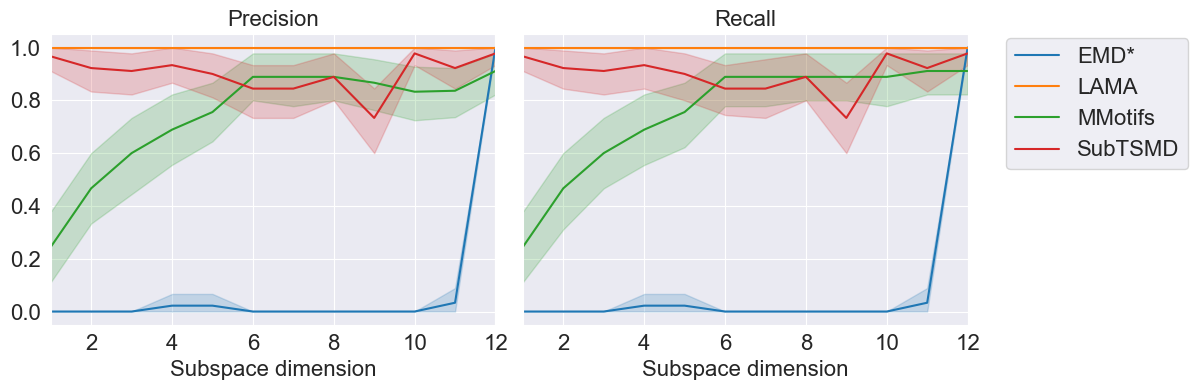

In [5]:
y_values = ['Precision', 'Recall']
fig, axs = plt.subplots(1, len(y_values), figsize=(10, 4), sharex='all', sharey='all')

for ax, y_value in zip(axs, y_values):
    sns.lineplot(
        df,
        x='Subspace dimension',
        y=y_value,
        hue='model',
        ax=ax
    )
    ax.set_title(y_value, fontsize=16)
    ax.set_ylabel('')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.get_legend().remove()
    ax.set_xlim([1, df['Subspace dimension'].max()])

lines_labels = [ax.get_legend_handles_labels() for ax in [fig.axes[0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(1, 0.92), fontsize=16)
    
fig.tight_layout()
fig.savefig("figures/fig-motif-pair-discovery.png", bbox_inches='tight')

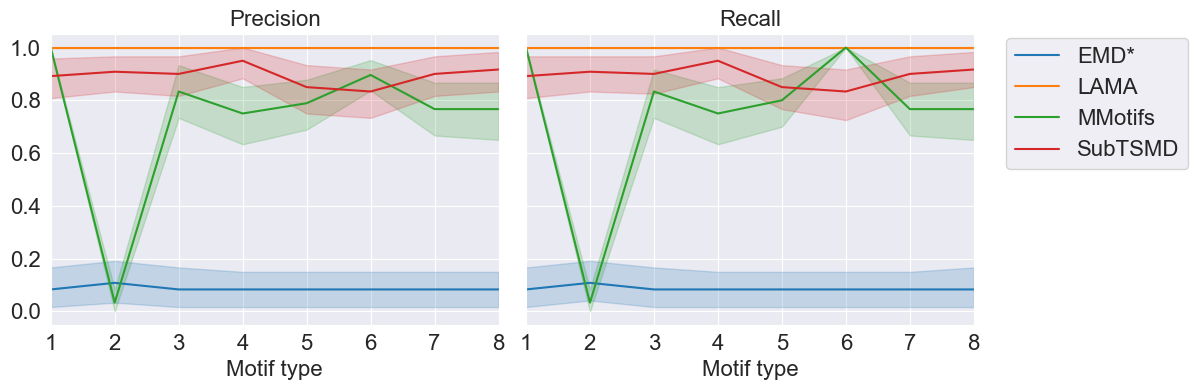

In [6]:
y_values = ['Precision', 'Recall']
fig, axs = plt.subplots(1, len(y_values), figsize=(10, 4), sharex='all', sharey='all')

for ax, y_value in zip(axs, y_values):
    sns.lineplot(
        df,
        x='Motif type',
        y=y_value,
        hue='model',
        ax=ax
    )
    ax.set_title(y_value, fontsize=16)
    ax.set_ylabel('')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.get_legend().remove()
    ax.set_xlim([1, df['Motif type'].max()])

lines_labels = [ax.get_legend_handles_labels() for ax in [fig.axes[0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(1, 0.92), fontsize=16)
    
fig.tight_layout()